<a href="https://www.kaggle.com/code/pavankumar960/consumer-behavior-analysis-predictive-model?scriptVersionId=309721277" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Project Setup

**Objective**

To analyze consumer demographics, digital behavior, and psychological scores to predict their primary shopping_preference (Store, Online, or Hybrid).

In [1]:
# Basic Libs
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math

#Visual Libs
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (20, 40)

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sohaibdevv/consumer-shopping-behavior-and-preference-study-2026/Consumer_Shopping_Trends_2026 (6).csv


# Loading Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sohaibdevv/consumer-shopping-behavior-and-preference-study-2026/Consumer_Shopping_Trends_2026 (6).csv")

# Data Overview

In [3]:
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [4]:
df.shape

(11789, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [6]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [7]:
df.nunique()

age                               62
monthly_income                 11504
daily_internet_hours             111
smartphone_usage_years            14
social_media_hours                61
online_payment_trust_score        10
tech_savvy_score                  10
monthly_online_orders             50
monthly_store_visits              20
avg_online_spend               11347
avg_store_spend                11324
discount_sensitivity              10
return_frequency                  10
avg_delivery_days                  7
delivery_fee_sensitivity          10
free_return_importance            10
product_availability_online       10
impulse_buying_score              10
need_touch_feel_score             10
brand_loyalty_score               10
environmental_awareness           10
time_pressure_level               10
gender                             3
city_tier                          3
shopping_preference                3
dtype: int64

In [8]:
cols = ['gender','city_tier','shopping_preference']
list(map(lambda i: print(f"Unique values in {i}: {df[i].unique()}"), cols))

Unique values in gender: ['Other' 'Male' 'Female']
Unique values in city_tier: ['Tier 3' 'Tier 1' 'Tier 2']
Unique values in shopping_preference: ['Store' 'Hybrid' 'Online']


[None, None, None]

In [9]:
df.isnull().sum()

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64

In [10]:
dup = df.duplicated().sum()
print(dup)

0


## Observation

* The dataset comprises 25 unique features, encompassing demographic, behavioral, and psychographic consumer data.
* Initial inspection confirms zero missing values across the dataset, requiring no immediate data imputation.
* Categorical variables such as gender, city_tier, and shopping_preference are candidates for numerical encoding (Label or One-Hot) to ensure model compatibility.
* The age variable can be binned into generational groups (e.g., 18–25, 26–35) to better capture non-linear behavioral trends.

# Data Visualization

## Univariate Analysis

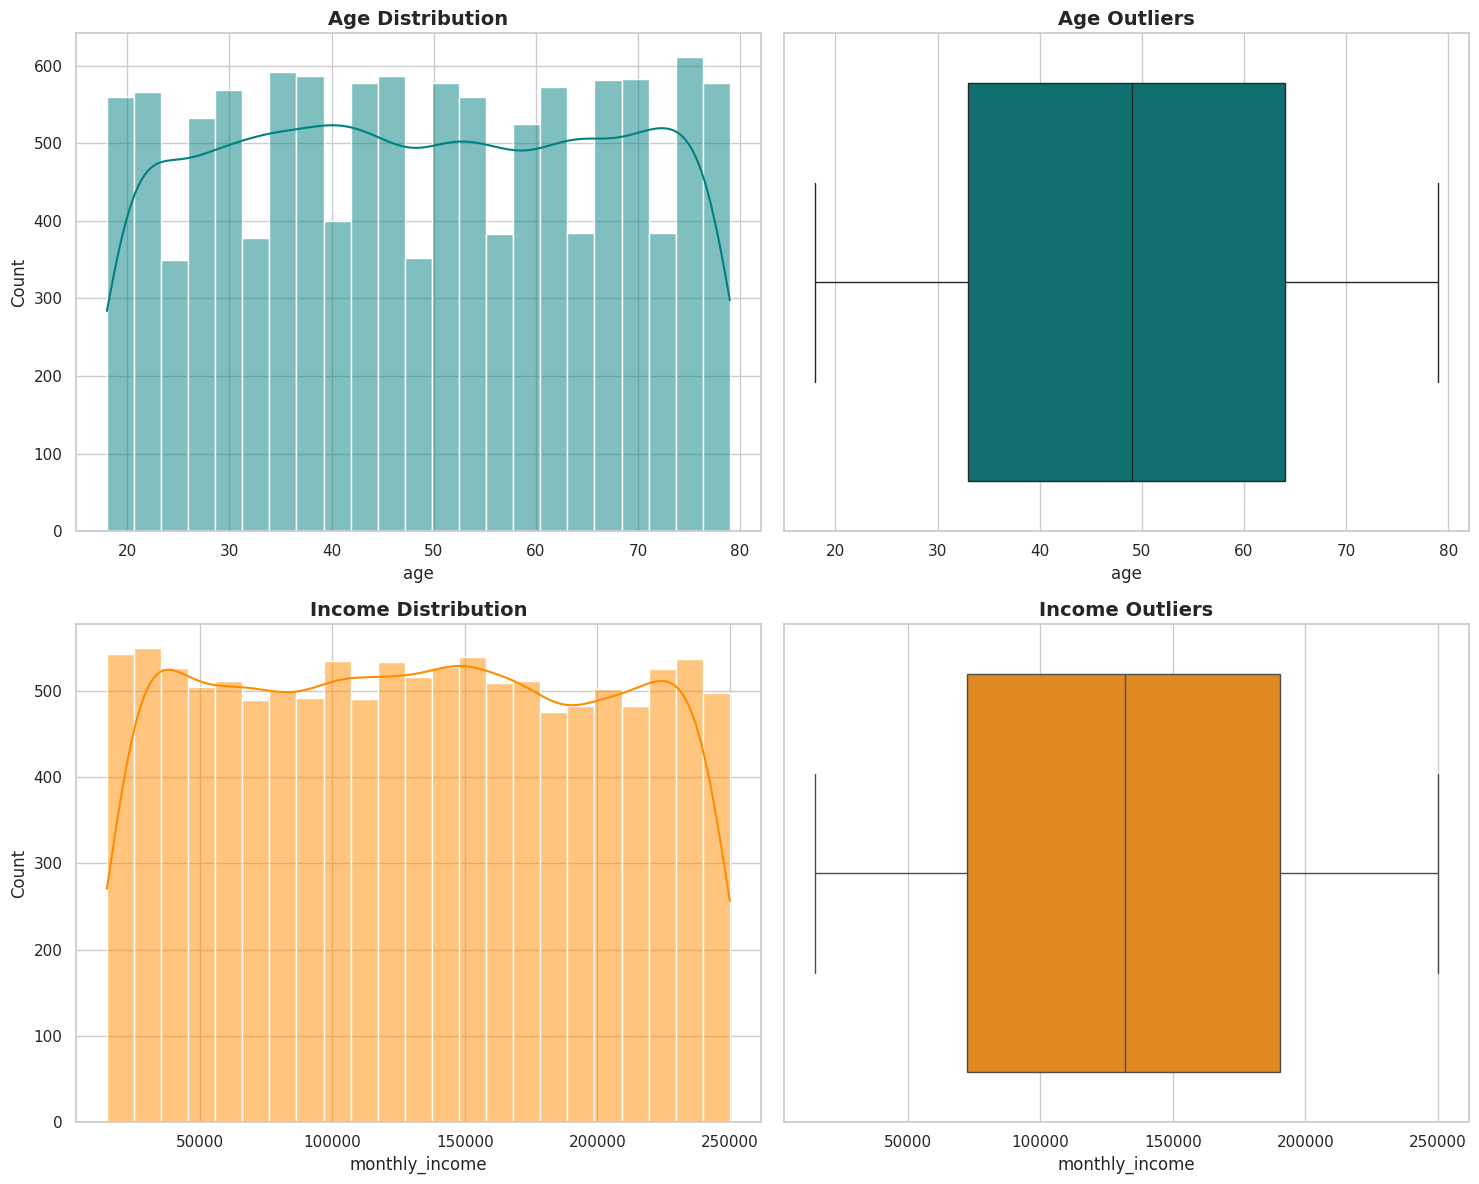

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax = axes.ravel() 

sns.histplot(df['age'], kde=True, ax=ax[0], color='teal')
ax[0].set_title('Age Distribution', fontsize=14, fontweight='bold')

sns.boxplot(x=df['age'], ax=ax[1], color='teal')
ax[1].set_title('Age Outliers', fontsize=14, fontweight='bold')

sns.histplot(df['monthly_income'], kde=True, ax=ax[2], color='darkorange')
ax[2].set_title('Income Distribution', fontsize=14, fontweight='bold')

sns.boxplot(x=df['monthly_income'], ax=ax[3], color='darkorange')
ax[3].set_title('Income Outliers', fontsize=14, fontweight='bold')

plt.tight_layout()
sns.set_style("white")
cols = ['daily_internet_hours', 'smartphone_usage_years', 'social_media_hours']
plt.show()

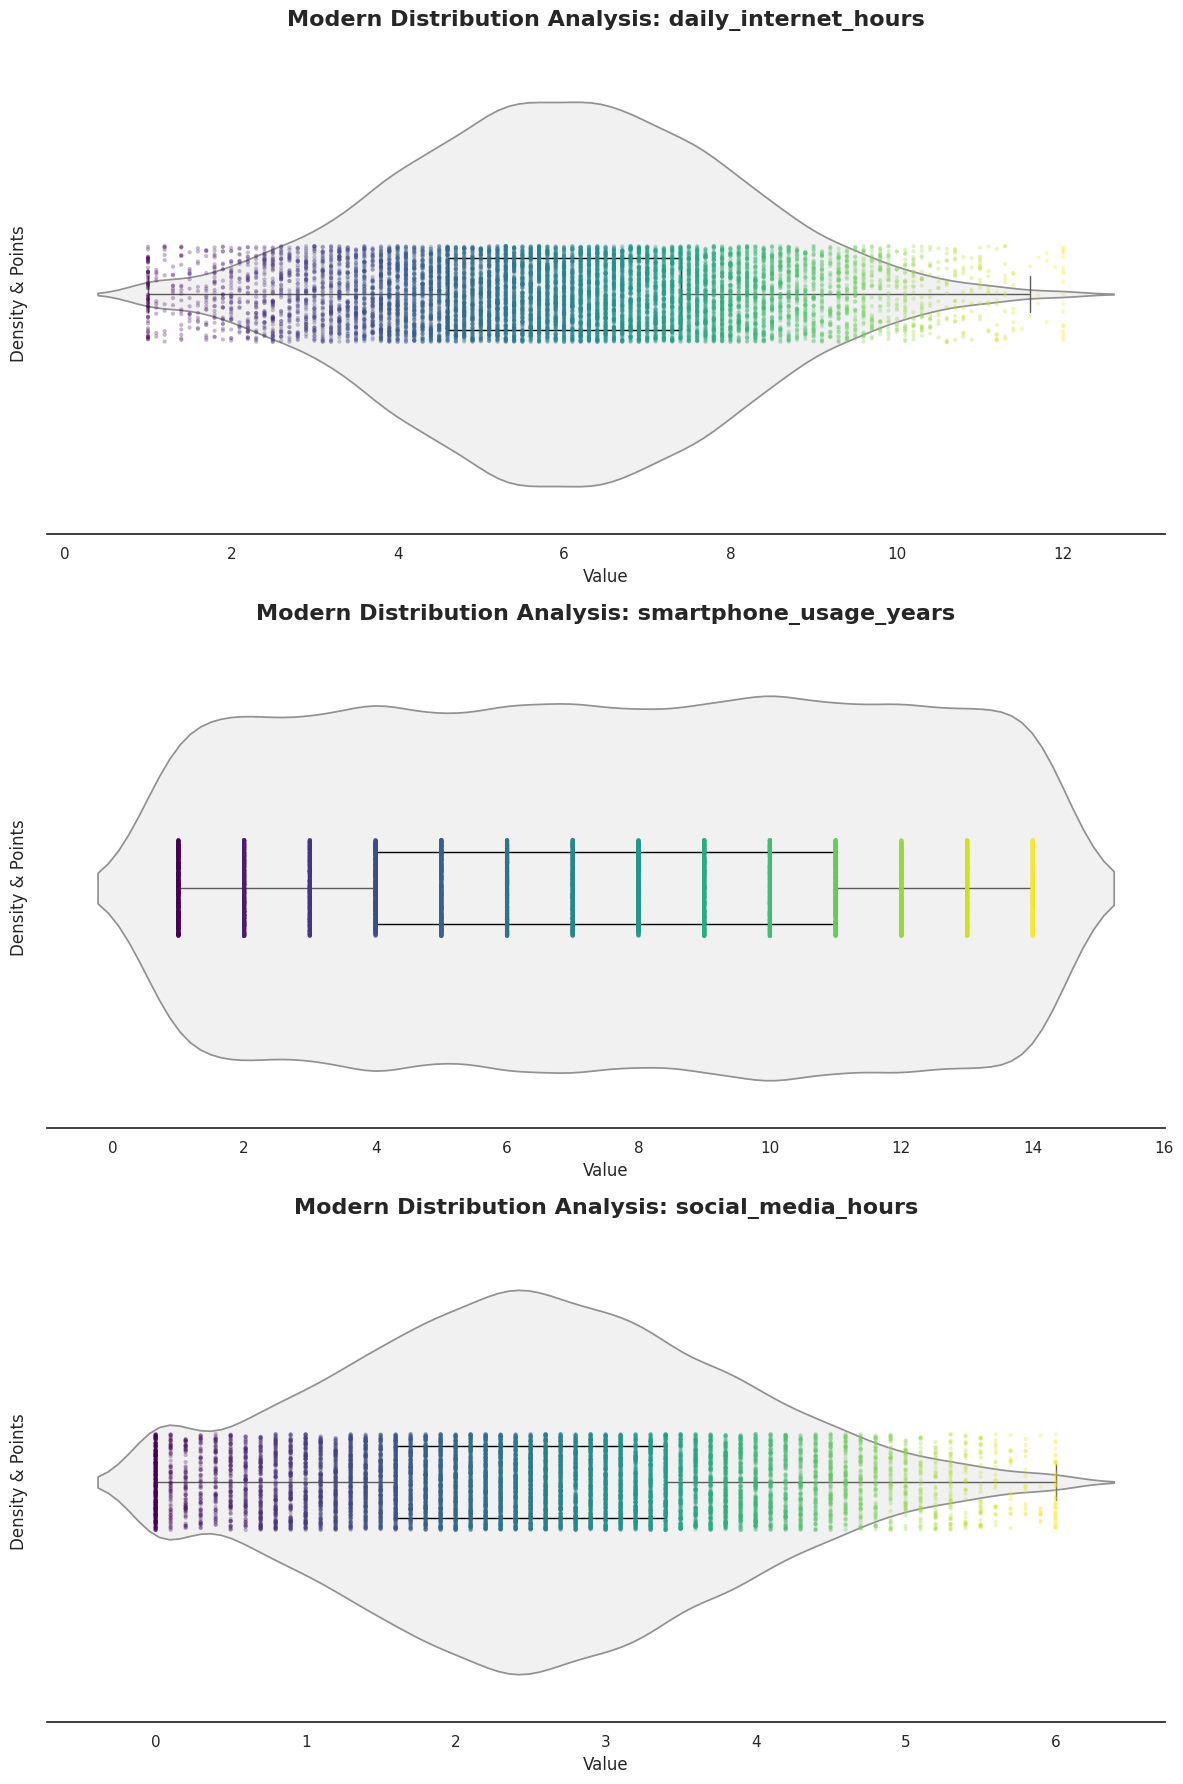

In [12]:
 sns.set_style("white")
 cols = ['daily_internet_hours', 'smartphone_usage_years', 'social_media_hours']

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for i, col in enumerate(cols):
    sns.violinplot(x=df[col], ax=axes[i], inner=None, color="#f1f1f1")
    sns.stripplot(x=df[col], ax=axes[i], alpha=0.3, size=3, jitter=True, palette="viridis", hue=df[col], legend=False)
    sns.boxplot(x=df[col], ax=axes[i], width=0.15, whis=1.5, showfliers=False, boxprops={'facecolor':'none', 'edgecolor':'black'})
    
    axes[i].set_title(f'Modern Distribution Analysis: {col}', fontsize=16, fontweight='bold', pad=20)
    axes[i].set_xlabel('Value', fontsize=12)
    axes[i].set_ylabel('Density & Points', fontsize=12)
    
    sns.despine(left=True)

plt.tight_layout()
plt.show()

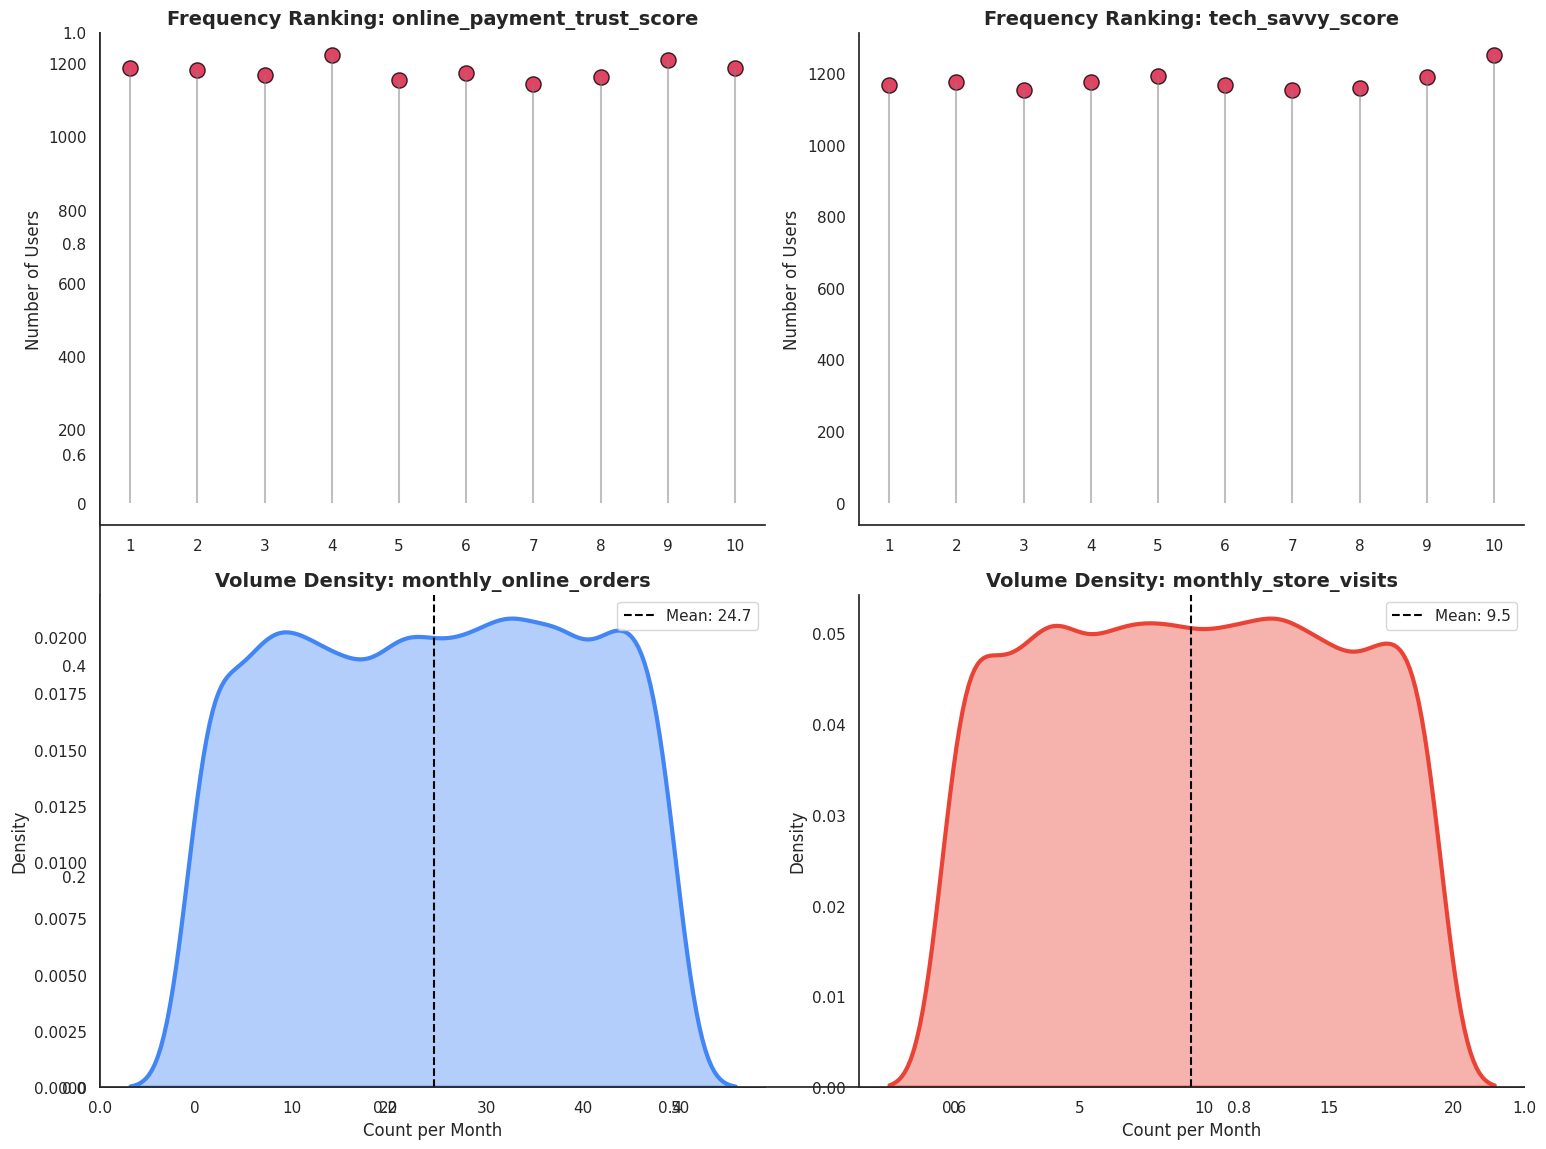

In [13]:
sns.set_style("white")
fig = plt.subplots(figsize=(16, 12))

score_cols = ['online_payment_trust_score', 'tech_savvy_score']
for i, col in enumerate(score_cols):
    plt.subplot(2, 2, i+1)
    
    data = df[col].value_counts().sort_index()
    
    plt.vlines(x=data.index, ymin=0, ymax=data.values, color='grey', alpha=0.5)
    plt.scatter(x=data.index, y=data.values, s=120, color='crimson', edgecolors="black", alpha=0.8)
    plt.title(f'Frequency Ranking: {col}', fontsize=14, fontweight='bold')
    plt.xticks(range(1, 11))
    plt.ylabel('Number of Users')
    sns.despine()

activity_cols = ['monthly_online_orders', 'monthly_store_visits']
colors = ['#4285F4', '#EA4335']

for i, col in enumerate(activity_cols):
    plt.subplot(2, 2, i+3)
    
    sns.kdeplot(df[col], fill=True, color=colors[i], alpha=0.4, linewidth=3)

    plt.axvline(df[col].mean(), color='black', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    plt.title(f'Volume Density: {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Count per Month')
    plt.legend()
    sns.despine()

plt.tight_layout()
plt.show()

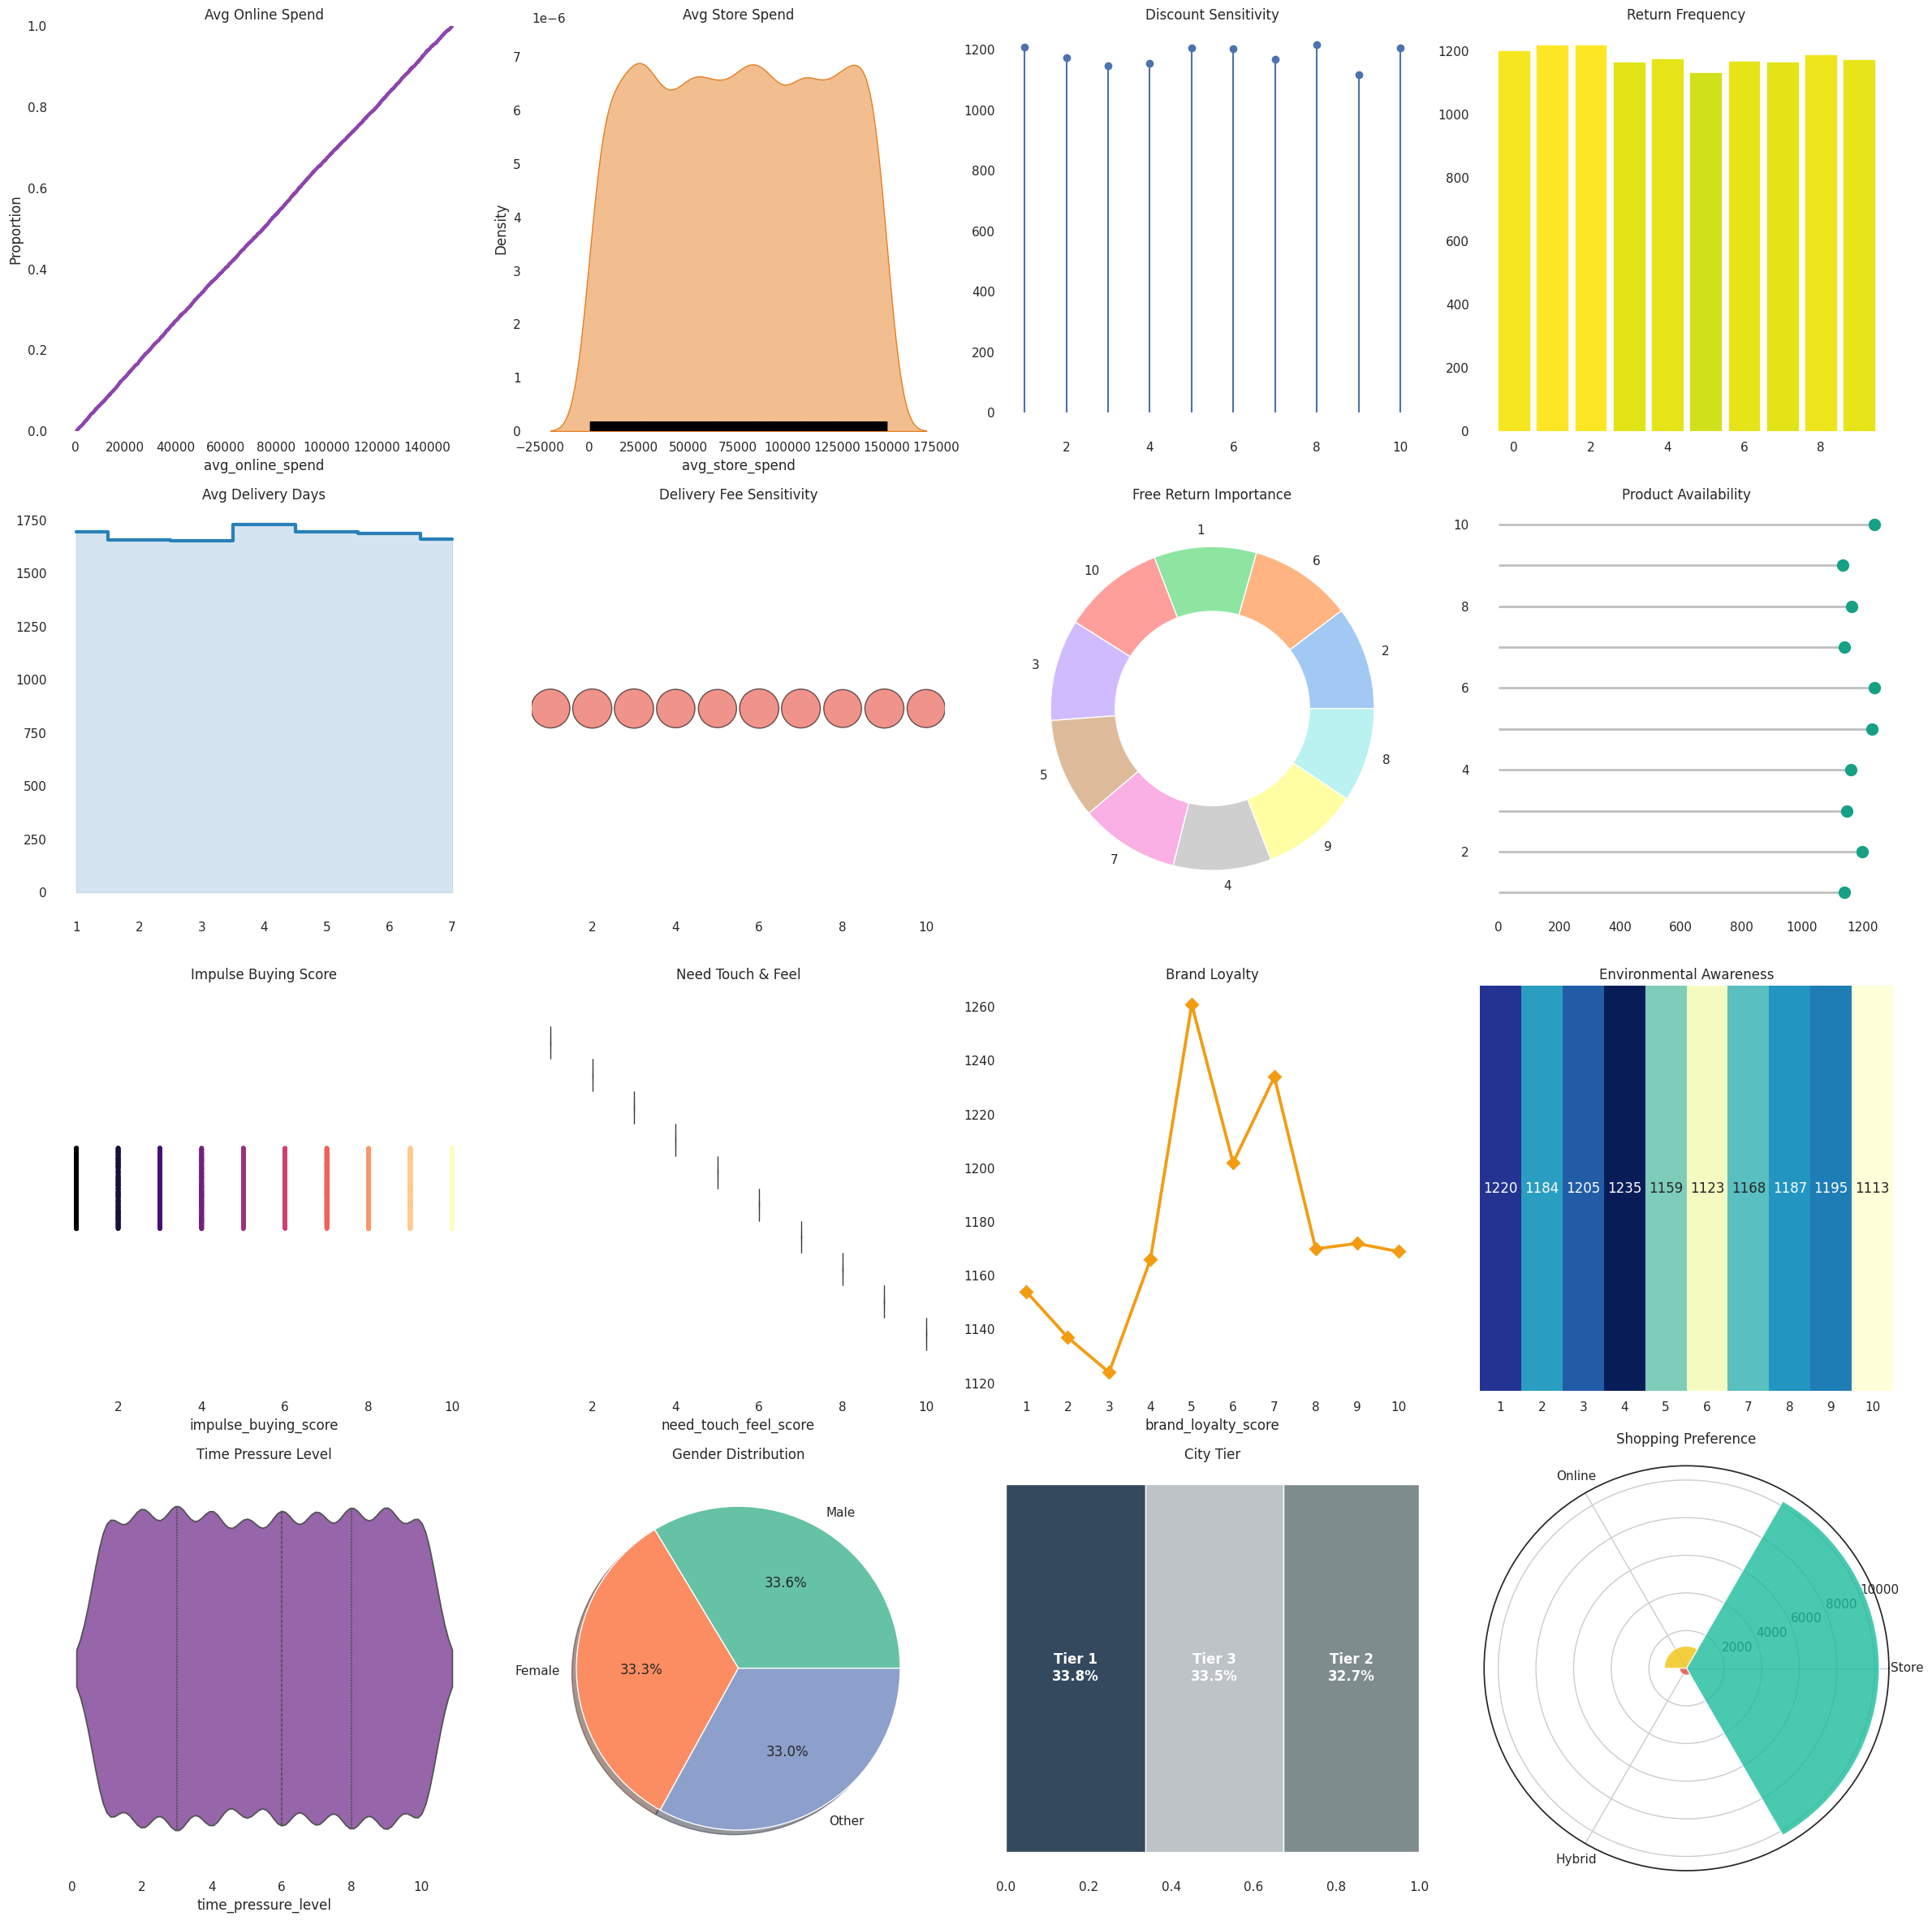

In [14]:
sns.set_theme(style="white")
fig = plt.figure(figsize=(24, 24))
plt.suptitle( "",fontsize=24, fontweight='bold', y=0.92)

ax1 = plt.subplot(4, 4, 1)
sns.ecdfplot(data=df, x='avg_online_spend', ax=ax1, color='#8E44AD', lw=3)
ax1.set_title('Avg Online Spend')

ax2 = plt.subplot(4, 4, 2)
sns.kdeplot(data=df, x='avg_store_spend', ax=ax2, fill=True, color='#E67E22', alpha=0.5)
sns.rugplot(data=df, x='avg_store_spend', ax=ax2, color='black', alpha=0.1)
ax2.set_title('Avg Store Spend')

ax3 = plt.subplot(4, 4, 3)
val3 = df['discount_sensitivity'].value_counts().sort_index()
ax3.stem(val3.index, val3.values, basefmt=" ", linefmt='-', markerfmt='o')
ax3.set_title('Discount Sensitivity')

ax4 = plt.subplot(4, 4, 4)
val4 = df['return_frequency'].value_counts().sort_index()
bars = ax4.bar(val4.index, val4.values)
for bar in bars:
    bar.set_color(plt.cm.viridis(bar.get_height() / max(val4.values)))
ax4.set_title('Return Frequency')

ax5 = plt.subplot(4, 4, 5)
val5 = df['avg_delivery_days'].value_counts().sort_index()
ax5.step(val5.index, val5.values, where='mid', color='#2980B9', lw=3)
ax5.fill_between(val5.index, val5.values, step="mid", alpha=0.2, color='#2980B9')
ax5.set_title('Avg Delivery Days')

ax6 = plt.subplot(4, 4, 6)
val6 = df['delivery_fee_sensitivity'].value_counts()
ax6.scatter(val6.index, [1]*len(val6), s=val6.values, color='#E74C3C', alpha=0.6, edgecolors='black')
ax6.set_yticks([]) 
ax6.set_title('Delivery Fee Sensitivity')

ax7 = plt.subplot(4, 4, 7)
val7 = df['free_return_importance'].value_counts()
ax7.pie(val7.values, labels=val7.index, wedgeprops=dict(width=0.4), colors=sns.color_palette('pastel'))
ax7.set_title('Free Return Importance')

ax8 = plt.subplot(4, 4, 8)
val8 = df['product_availability_online'].value_counts().sort_index()
ax8.hlines(y=val8.index, xmin=0, xmax=val8.values, color='gray', alpha=0.5, lw=2)
ax8.scatter(val8.values, val8.index, s=100, color='#16A085', zorder=3)
ax8.set_title('Product Availability')

ax9 = plt.subplot(4, 4, 9)
sns.stripplot(x=df['impulse_buying_score'], ax=ax9, hue=df['impulse_buying_score'], jitter=True, alpha=0.3, size=4, palette='magma', legend=False)
ax9.set_title('Impulse Buying Score')

ax10 = plt.subplot(4, 4, 10)
sns.boxenplot(x=df['need_touch_feel_score'], ax=ax10, hue=df['need_touch_feel_score'], palette='coolwarm', legend=False)
ax10.set_title('Need Touch & Feel')

ax11 = plt.subplot(4, 4, 11)
val11 = df['brand_loyalty_score'].value_counts().sort_index()
sns.pointplot(x=val11.index, y=val11.values, ax=ax11, color='#F39C12', markers='D')
ax11.set_title('Brand Loyalty')

ax12 = plt.subplot(4, 4, 12)
val12 = df['environmental_awareness'].value_counts().sort_index().values.reshape(1, -1)
sns.heatmap(val12, cmap='YlGnBu', annot=True, fmt='d', cbar=False, ax=ax12, yticklabels=False, xticklabels=range(1,11))
ax12.set_title('Environmental Awareness')

ax13 = plt.subplot(4, 4, 13)
sns.violinplot(x=df['time_pressure_level'], ax=ax13, color='#9B59B6', inner='quartile')
ax13.set_title('Time Pressure Level')

ax14 = plt.subplot(4, 4, 14)
val14 = df['gender'].value_counts()
ax14.pie(val14.values, labels=val14.index, autopct='%1.1f%%', shadow=True, colors=sns.color_palette('Set2'))
ax14.set_title('Gender Distribution')

ax15 = plt.subplot(4, 4, 15)
val15 = df['city_tier'].value_counts(normalize=True)
left = 0
colors = ['#34495E', '#BDC3C7', '#7F8C8D']
for i, (idx, val) in enumerate(val15.items()):
    ax15.barh('City Tier', val, left=left, color=colors[i], edgecolor='white', label=idx)
    ax15.text(left + val/2, 0, f'{idx}\n{val*100:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    left += val
ax15.set_xlim(0, 1)
ax15.set_yticks([]) 
ax15.set_title('City Tier')

ax16 = plt.subplot(4, 4, 16, polar=True)
val16 = df['shopping_preference'].value_counts()
theta = np.linspace(0.0, 2 * np.pi, len(val16), endpoint=False)
width = 2 * np.pi / len(val16)
bars = ax16.bar(theta, val16.values, width=width, bottom=0.0, color=['#1ABC9C', '#F1C40F', '#E74C3C'], alpha=0.8)
ax16.set_xticks(theta)
ax16.set_xticklabels(val16.index)
ax16.set_title('Shopping Preference', pad=20)

for ax in fig.axes:
    if ax.name != 'polar':
        sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

### Observation

* Age is uniformly balanced from 18 to 79, ensuring no demographic bias.

* Monthly income shows a high-quality uniform balance with roughly 500 samples per bracket between 15k and 250k.

* Daily internet hours follow a normal bell curve, peaking moderately around 6 hours with rare extremes.

* Smartphone usage years are perfectly uniform from 1 to 14 years, giving equal weight to early adopters and digital natives.

* Social media hours are right-skewed with a peak at 2.5 hours and a notable behavioral spike among minimalists at 0-0.5 hours.

* Online payment trust score is perfectly balanced across the 1-10 scale with approximately 1,200 users per rating tier.

* Tech-savvy score maintains a uniform distribution, also capturing around 1,200 users evenly in each rating level.

* Monthly online orders center around a robust mean of 24.7, indicating highly active digital engagement.

* Monthly store visits show significantly lower engagement with a mean of 9.5, indicating less frequent physical retail trips.

* Average online spend exhibits a steady, positive cumulative growth trend across the user base.

* Average store spend (along with several other continuous metrics) displays a stable, uniform distribution.

* Need touch and feel score follows a sharp decaying trend where a score of 1 is the most frequent, confirming a very low reliance on physical product inspection.

* Brand loyalty score clusters moderately in the mid-to-high range (scores 5-7), with notably fewer users exhibiting extremely low loyalty.

* Shopping preference reveals a severe class imbalance heavily dominated by physical store shoppers (~10,000) compared to online (~1,000) and hybrid (~100), which will require specific sampling techniques before predictive modeling.

## Bivariate Analysis

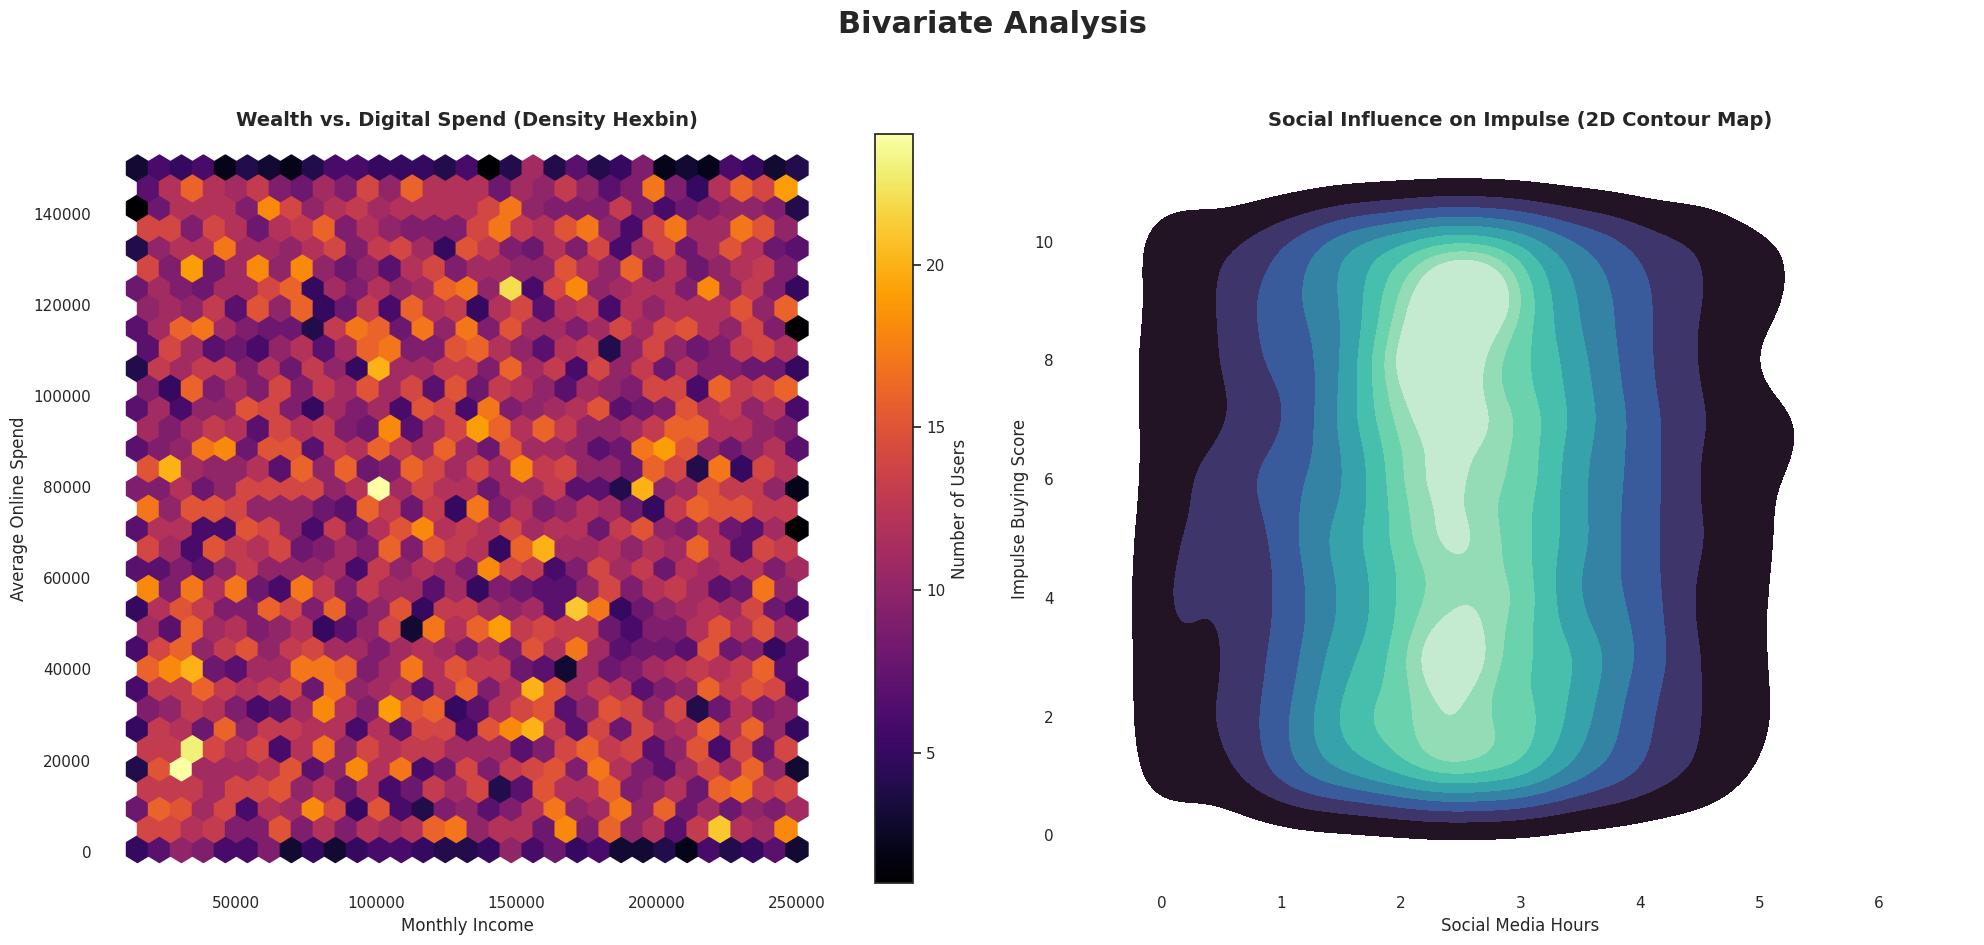

In [15]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
fig = plt.figure(figsize=(20, 18))
plt.suptitle("Bivariate Analysis", fontsize=22, fontweight='bold', y=0.95)

ax1 = plt.subplot(2, 2, 1)
hb = ax1.hexbin(df['monthly_income'], df['avg_online_spend'], gridsize=30, cmap='inferno', mincnt=1)
cb = fig.colorbar(hb, ax=ax1, label='Number of Users')
ax1.set_title('Wealth vs. Digital Spend (Density Hexbin)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Monthly Income')
ax1.set_ylabel('Average Online Spend')

ax2 = plt.subplot(2, 2, 2)
sns.kdeplot(data=df, x='social_media_hours', y='impulse_buying_score', 
            fill=True, thresh=0.05, levels=10, cmap="mako", ax=ax2)
ax2.set_title('Social Influence on Impulse (2D Contour Map)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Social Media Hours')
ax2.set_ylabel('Impulse Buying Score')

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Observation

* Income vs. Online Spend : Demonstrates zero correlation ("white noise"), meaning users with lower incomes are spending just as much online as high-income earners.

* Social Media vs. Impulse Buying:  Reveals no causal relationship, as the visual density simply reflects the bulk of users spending 2-3 hours on social media regardless of their impulse buying score.

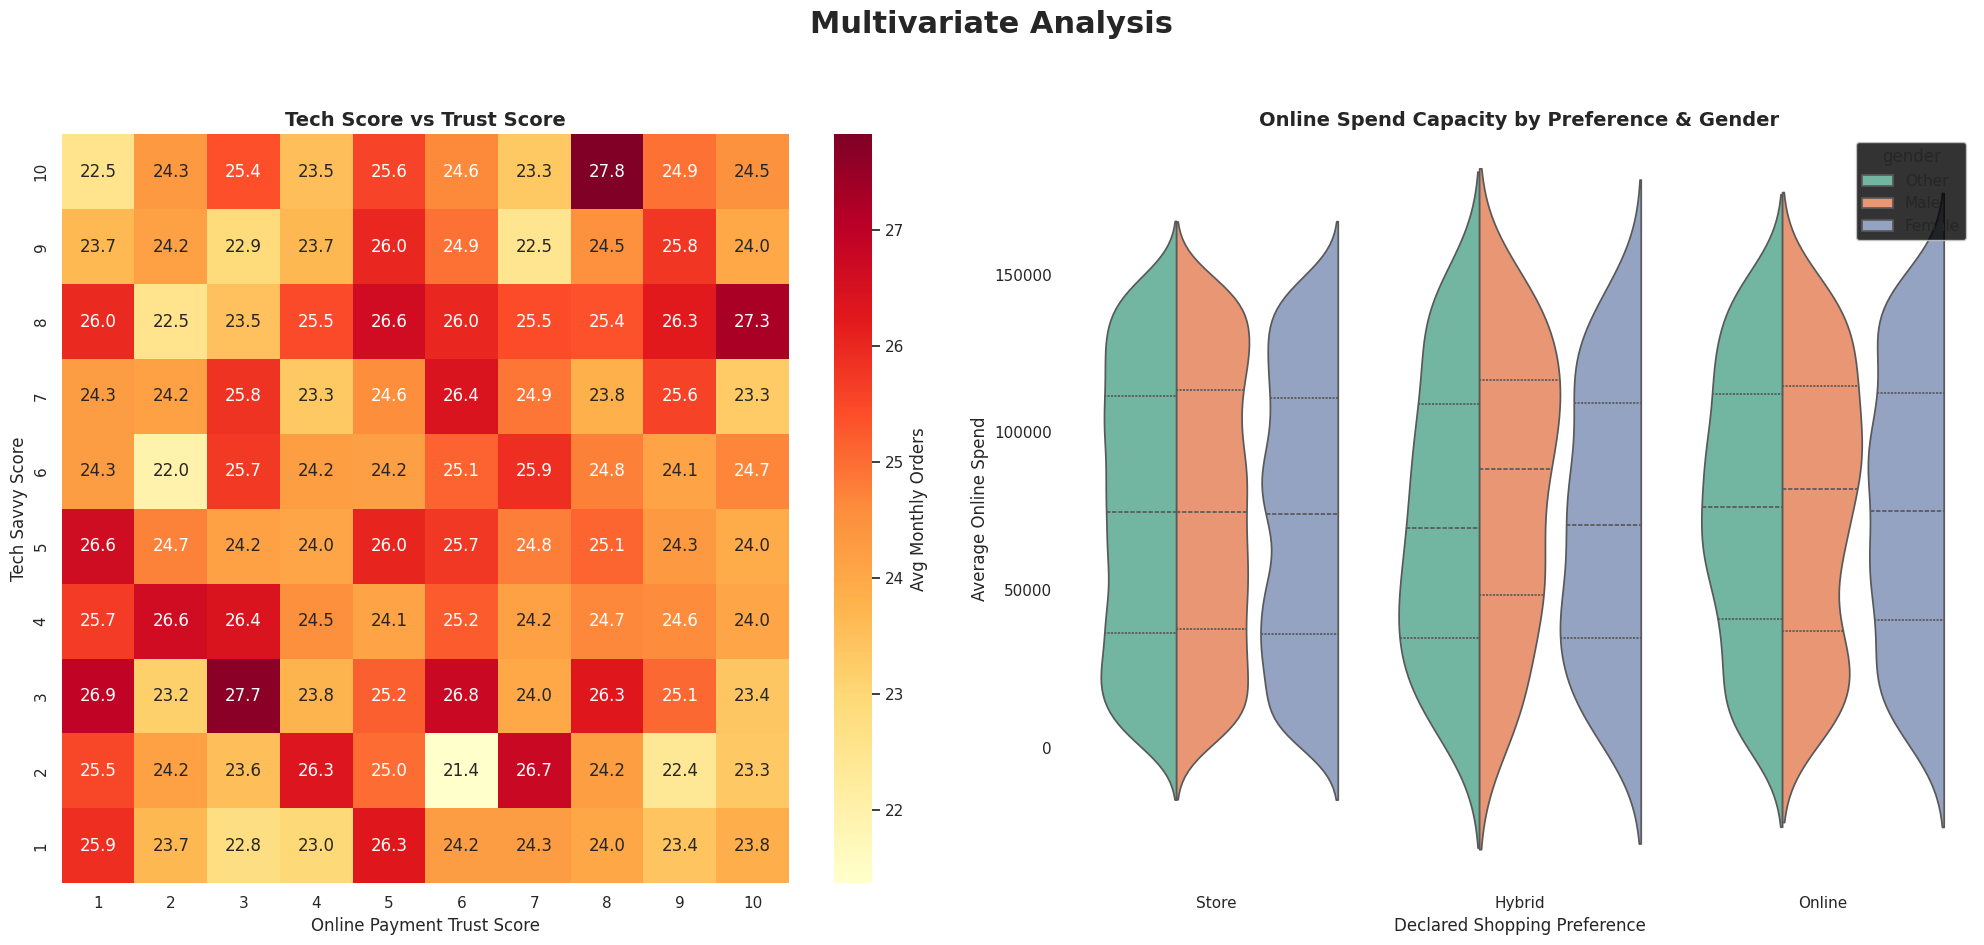

<Figure size 2000x4000 with 0 Axes>

In [16]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
fig = plt.figure(figsize=(20, 18))
plt.suptitle("Multivariate Analysis", fontsize=22, fontweight='bold', y=0.95)

ax1 = plt.subplot(2, 2, 1)
pivot_data = df.pivot_table(values='monthly_online_orders', 
                            index='tech_savvy_score', 
                            columns='online_payment_trust_score', 
                            aggfunc='mean')
sns.heatmap(pivot_data, cmap='YlOrRd', annot=True, fmt=".1f", cbar_kws={'label': 'Avg Monthly Orders'}, ax=ax1)
ax1.invert_yaxis()
ax1.set_title('Tech Score vs Trust Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('Online Payment Trust Score')
ax1.set_ylabel('Tech Savvy Score')

ax2 = plt.subplot(2, 2, 2)
sns.violinplot(data=df, x='shopping_preference', y='avg_online_spend', hue='gender', 
               split=True, inner="quart", palette="Set2", ax=ax2)
ax2.set_title('Online Spend Capacity by Preference & Gender', fontsize=14, fontweight='bold')
ax2.set_xlabel('Declared Shopping Preference')
ax2.set_ylabel('Average Online Spend')

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Observation

* Tech Savvy & Trust vs. Online Orders: Displays minor localized fluctuations (e.g., a peak of 27.8 orders at high tech/trust), but lacks a strong directional trend, indicating these scores do not heavily dictate order volume.

* Shopping Preference & Gender vs. Online Spend: Shows identical overall spending capacities across all declared preferences, though male users exhibit a marginal spending advantage in the Online and Hybrid categories.

# Model Training

In [17]:
df_ml = df.copy()

df_ml = pd.get_dummies(df_ml, columns=['gender', 'city_tier'], drop_first=True)

X = df_ml.drop('shopping_preference', axis=1)
y = df_ml['shopping_preference']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
print("Training the Random Forest Baseline Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

Training the Random Forest Baseline Model...


RandomForestClassifier(random_state=42)

# Evaluation


 Model Evaluation
              precision    recall  f1-score   support

      Hybrid       1.00      0.01      0.03        72
      Online       0.86      0.91      0.89       224
       Store       0.97      1.00      0.98      2062

    accuracy                           0.96      2358
   macro avg       0.94      0.64      0.63      2358
weighted avg       0.96      0.96      0.94      2358



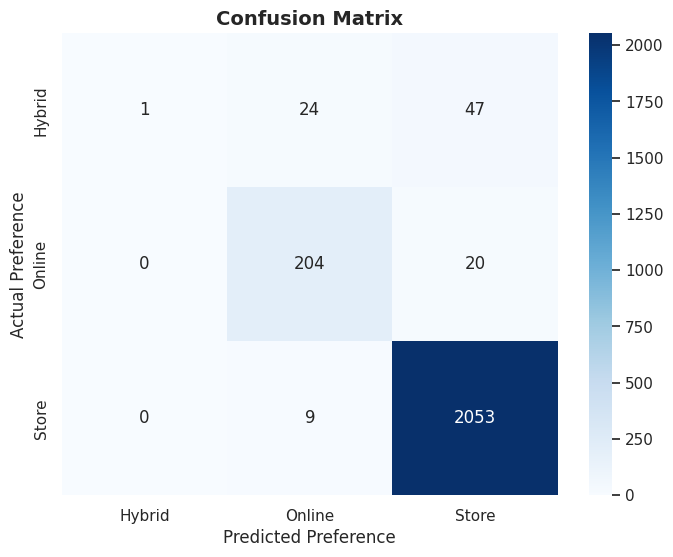


Top 5 Most Important Features
avg_store_spend          0.563661
need_touch_feel_score    0.043350
tech_savvy_score         0.033013
monthly_online_orders    0.032130
daily_internet_hours     0.027268
dtype: float64


In [18]:
# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation & Results
print("\n Model Evaluation")
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Preference')
plt.xlabel('Predicted Preference')
plt.show()

# Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Most Important Features")
print(feature_importances.head(5))

# Conclusion

**Exploratory Data Analysis (EDA) Findings**

* Demographic Stability: The dataset contains 11,789 users with a highly uniform distribution across age (18-79) and monthly income ($15k-$250k).

* Behavioral Imbalance: A severe class imbalance was identified in the target variable, with approximately 85% of users declaring a preference for "Store" shopping, while actual digital engagement (average online spend and monthly online orders) remained robust.

* Absence of Correlation: High-density bivariate and multivariate visualizations (Hexbins, Contour Maps) revealed no organic correlation between key financial and psychological metrics (e.g., Income vs. Online Spend, Social Media Hours vs. Impulse Buying).

**Baseline Predictive Modeling**

* A Random Forest Classifier was trained to predict shopping_preference using the unscaled, imbalanced dataset to establish a baseline.

* The Accuracy Paradox: The model achieved seemingly high overall accuracy by defaulting almost entirely to the majority class ("Store"), resulting in a near-zero recall for "Online" and "Hybrid" shoppers.

* Feature Importance: The model relied heavily on continuous variables with high variance (e.g., avg_store_spend accounted for 56% of decision weight), further indicating a lack of meaningful behavioral patterns in the categorical features.